# Library Import

In [1]:
# 한국어 텍스트 감정 분석을 위한 필수 라이브러리들
from collections import Counter  # 카운터 자료구조
import os  # 운영체제 인터페이스
import platform  # 플랫폼 정보
import re  # 정규 표현식
import sys  # 시스템 정보
import warnings  # 경고 메시지 제어


import matplotlib.pyplot as plt  # 데이터 시각화
plt.rc("font", family="NanumBarunGothic")  # 한글 폰트 설정(없으면 설치 필요)

import numpy as np  # 수치 연산
import pandas as pd  # 데이터 처리 및 분석
import seaborn as sns  # 고급 시각화
import torch  # 딥러닝 프레임워크
import koreanize_matplotlib

# 머신러닝 관련 라이브러리
from sklearn.metrics import accuracy_score, f1_score  # 평가 지표
from sklearn.model_selection import train_test_split  # 데이터 분할

# 트랜스포머 및 BERT 관련 라이브러리
from transformers import (
    AutoModelForSequenceClassification,  # 시퀀스 분류 모델
    AutoTokenizer,  # 토크나이저
    DataCollatorWithPadding,  # 패딩 데이터 콜레이터
    set_seed,
    Trainer,  # 트레이너
    TrainingArguments,  # 훈련 설정
)

# PyTorch 데이터 처리
from torch.utils.data import Dataset  # 데이터셋 및 데이터로더

# 경고 메시지 필터링
warnings.filterwarnings("ignore")

# 라이브러리 버전 정보 출력 (재현성을 위함)
print("=== 라이브러리 버전 정보 ===")
print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"torch: {torch.__version__}")
print(f"transformers: {__import__('transformers').__version__}")
print(f"sklearn: {__import__('sklearn').__version__}")
print(f"matplotlib: {__import__('matplotlib').__version__}")
print(f"seaborn: {sns.__version__}")

# GPU 사용 가능 여부 확인
print("\n=== PyTorch GPU 지원 정보 ===")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 버전: {torch.version.cuda}")
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU: {torch.cuda.current_device()}")
    print(f"GPU 이름: {torch.cuda.get_device_name()}")
else:
    print("CPU에서 실행 중")

=== 라이브러리 버전 정보 ===
Python: 3.10.13 (main, Sep 11 2023, 13:44:35) [GCC 11.2.0]
Platform: Linux-5.4.0-99-generic-x86_64-with-glibc2.31
pandas: 2.2.3
numpy: 2.2.6
torch: 2.6.0+cu124
transformers: 4.55.0
sklearn: 1.6.1
matplotlib: 3.10.5
seaborn: 0.13.2

=== PyTorch GPU 지원 정보 ===
CUDA 사용 가능: True
CUDA 버전: 12.4
GPU 개수: 1
현재 GPU: 0
GPU 이름: Tesla V100-SXM2-32GB


## Random Seed Configuration

In [2]:
# 랜덤 시드 설정
RANDOM_STATE = 42


set_seed(RANDOM_STATE)

print(f"랜덤 시드 {RANDOM_STATE}로 설정 완료")

랜덤 시드 42로 설정 완료


# Data Load

In [3]:
# 데이터 로드
df = pd.read_csv("../../../data/raw/train.csv")

# 처음 몇 행 표시
print("\n처음 5행:")
df.head()


처음 5행:


,ID,review,label,type
0,0,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,2,augment
1,1,어느 부잣집 도련님의 철없는 행각,1,original
2,3,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,0,original
3,4,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,2,augment
4,5,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,0,original


# Data/Feature Engineering

## 텍스트 전처리 및 정리

- 기본 텍스트 정리 (특수문자 제거, 공백 정규화)
- 필요시 한국어 특화 전처리 처리
- 매우 짧거나 긴 텍스트 제거 또는 처리
- 중복 제거

In [4]:
# 데이터 전처리를 위한 복사본 생성
df_processed = df[["ID", "label", "review", "type"]].copy()

print(f"원본 데이터셋 크기: {len(df_processed):,}개")

df_processed.head()

원본 데이터셋 크기: 279,650개


,ID,label,review,type
0,0,2,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,augment
1,1,1,어느 부잣집 도련님의 철없는 행각,original
2,3,0,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,original
3,4,2,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,augment
4,5,0,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,original


In [5]:
# 기본 텍스트 정리 함수
def clean_text(text):
    """
    한국어 텍스트를 위한 기본 텍스트 정리 함수

    전처리 단계:
    1. 불완전한 한글 제거 (자음/모음만 있는 경우)
    2. 반복되는 감정 표현 정규화 (ㅋㅋㅋ, ㅠㅠㅠ 등)
    3. 과도한 문자 반복 축소 (4번 이상 → 3번으로)
    4. 특수문자 제거 (한글, 숫자, 기본 구두점, 감정표현 제외)
    5. 공백 정규화
    """
    if pd.isna(text):
        return ""

    text = str(text).strip()

    # 한국어 특화 전처리
    text = re.sub(
        r"[ㄱ-ㅎㅏ-ㅣ]+", "", text
    )  # 불완전한 한글 제거 (자음/모음만 있는 경우)
    text = re.sub(r"([ㅋㅎ])\1{2,}", r"\1\1", text)  # 웃음 표현 정규화: ㅋㅋㅋ+ → ㅋㅋ
    text = re.sub(
        r"([ㅠㅜㅡ])\1{2,}", r"\1\1", text
    )  # 슬픔 표현 정규화: ㅠㅠㅠ+ → ㅠㅠ
    text = re.sub(
        r"(.)\1{3,}", r"\1\1\1", text
    )  # 과도한 반복 축소: 4번 이상 반복 → 3번으로
    text = re.sub(r"[^\w\s가-힣.,!?ㅋㅎㅠㅜㅡ~\-]", " ", text)  # 필요한 문자만 유지
    text = re.sub(r"\s+", " ", text)  # 다중 공백을 단일 공백으로

    return text.strip()


print("텍스트 전처리 과정 시작")
print("=" * 50)
initial_size = len(df_processed)
print(f"초기 데이터 크기: {initial_size:,}개")

# 1단계: 텍스트 정리 적용
print("\n1단계: 기본 텍스트 정리 수행 중...")
df_processed["review_cleaned"] = df_processed["review"].apply(clean_text)
print("✓ 한글 자음/모음 정리, 반복 표현 정규화, 특수문자 제거 완료")

# 2단계: 빈 텍스트 제거
print("\n2단계: 빈 텍스트 제거 중...")
empty_count = df_processed["review_cleaned"].str.strip().eq("").sum()
if empty_count > 0:
    df_processed = df_processed[df_processed["review_cleaned"].str.strip() != ""]
    print(f"✓ 빈 텍스트 {empty_count}개 제거")
else:
    print("✓ 빈 텍스트 없음")

# 3단계: 중복 제거
print("\n3단계: 중복 데이터 제거 중...")
duplicates_count = df_processed.duplicated(subset=["review_cleaned", "label"]).sum()
if duplicates_count > 0:
    df_processed = df_processed.drop_duplicates(subset=["review_cleaned", "label"])
    print(f"✓ 중복 데이터 {duplicates_count}개 제거")
else:
    print("✓ 중복 데이터 없음")

# 최종 결과 요약
final_size = len(df_processed)
removed = initial_size - final_size
print("\n" + "=" * 50)
print("전처리 결과 요약:")
print(f"최종 데이터 크기: {initial_size:,} → {final_size:,}")
print(f"제거된 데이터: {removed:,}개 ({removed / initial_size * 100:.1f}%)")
print("=" * 50)

텍스트 전처리 과정 시작
초기 데이터 크기: 279,650개

1단계: 기본 텍스트 정리 수행 중...
✓ 한글 자음/모음 정리, 반복 표현 정규화, 특수문자 제거 완료

2단계: 빈 텍스트 제거 중...
✓ 빈 텍스트 362개 제거

3단계: 중복 데이터 제거 중...
✓ 중복 데이터 3589개 제거

전처리 결과 요약:
최종 데이터 크기: 279,650 → 275,699
제거된 데이터: 3,951개 (1.4%)


## 텍스트 정규화

- 대소문자 정규화 (BERT가 처리하지만)
- 구두점 처리
- 특수문자 처리
- URL/이메일/멘션 정리 (있는 경우)

In [6]:
print("텍스트 정규화 과정 시작")
print("=" * 50)

# 대소문자 정규화 (BERT가 처리하지만 일관성을 위해)
print("\n1단계: 대소문자 정규화 수행 중...")
df_processed["review_normalized"] = df_processed["review_cleaned"].str.lower()
print("✓ 소문자 변환 완료")

# 구두점 정규화
print("\n2단계: 구두점 정규화 수행 중...")


def normalize_punctuation(text):
    # 여러 개의 구두점을 하나로 정규화
    text = re.sub(r"[.]{2,}", ".", text)
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)
    text = re.sub(r"[,]{2,}", ",", text)

    # 구두점 주변 공백 정리
    text = re.sub(r"\s+([.,!?])", r"\1", text)
    text = re.sub(r"([.,!?])\s+", r"\1 ", text)

    return text


df_processed["review_normalized"] = df_processed["review_normalized"].apply(
    normalize_punctuation
)
print("✓ 구두점 정규화 완료")

# 특수문자 추가 정리
print("\n3단계: 특수문자 정리 수행 중...")


def clean_special_chars(text):
    # URL 패턴 제거 (있는 경우)
    text = re.sub(
        r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
        "",
        text,
    )

    # 이메일 패턴 제거 (있는 경우)
    text = re.sub(r"\S+@\S+", "", text)

    # 멘션 패턴 제거 (있는 경우)
    text = re.sub(r"@\w+", "", text)

    # 과도한 공백 정리
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df_processed["review_normalized"] = df_processed["review_normalized"].apply(
    clean_special_chars
)
print("✓ URL/이메일/멘션 제거 완료")

# 정규화 후 빈 텍스트 처리
print("\n4단계: 정규화 후 빈 텍스트 확인 중...")
empty_after_normalization = df_processed["review_normalized"].str.strip().eq("").sum()
if empty_after_normalization > 0:
    df_processed = df_processed[df_processed["review_normalized"].str.strip() != ""]
    print(f"✓ 빈 텍스트 {empty_after_normalization}개 제거")
else:
    print("✓ 빈 텍스트 없음")

# 정규화 전후 비교
print("\n" + "=" * 50)
print("정규화 결과 요약:")
print(f"최종 데이터 크기: {len(df_processed):,}개")
print(f"평균 길이 - 정리됨: {df_processed['review_cleaned'].str.len().mean():.1f}자")
print(
    f"평균 길이 - 정규화됨: {df_processed['review_normalized'].str.len().mean():.1f}자"
)
print("=" * 50)

텍스트 정규화 과정 시작

1단계: 대소문자 정규화 수행 중...
✓ 소문자 변환 완료

2단계: 구두점 정규화 수행 중...
✓ 구두점 정규화 완료

3단계: 특수문자 정리 수행 중...
✓ URL/이메일/멘션 제거 완료

4단계: 정규화 후 빈 텍스트 확인 중...
✓ 빈 텍스트 없음

정규화 결과 요약:
최종 데이터 크기: 275,699개
평균 길이 - 정리됨: 158.3자
평균 길이 - 정규화됨: 157.3자


In [7]:
# 데이터 확인
df_processed.head()

,ID,label,review,type,review_cleaned,review_normalized
0,0,2,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,augment,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...
1,1,1,어느 부잣집 도련님의 철없는 행각,original,어느 부잣집 도련님의 철없는 행각,어느 부잣집 도련님의 철없는 행각
2,3,0,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,original,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네
3,4,2,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,augment,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...
4,5,0,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,original,참나이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨걍 다른 드라마랑 똑같구만 사랑이야...,참나이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨걍 다른 드라마랑 똑같구만 사랑이야...


## 텍스트 전처리 파이프라인 재구성

- 앞서 정의한 전처리 및 정규화 함수들을 활용하여 재사용 가능한 파이프라인 구성
- 또한 학습/검증 데이터 분리 시 데이터 누수(Data Leakage)를 방지하기 위한 전략 포함

데이터 누수 방지 전략:
- 전처리 파라미터는 학습 데이터에서만 학습
- 검증/테스트 데이터는 학습된 파라미터로만 변환
- 레이블 정보를 활용한 전처리는 학습 시에만 적용

In [8]:
class TextPreprocessingPipeline:
    def __init__(self):
        self.is_fitted = False
        self.vocab_info = {}
        self.label_patterns = {}
        # text_preprocessing.ipynb에서 개발된 추가 전처리 규칙 저장
        self.advanced_rules = {}  

    def basic_preprocess(self, texts):
        """기본 전처리 (clean_text + normalize 기능)"""
        processed_texts = []
        for text in texts:
            # 기본 텍스트 정리
            cleaned = self._clean_text(text)
            # 정규화
            normalized = self._normalize_text(cleaned)
            processed_texts.append(normalized)
        return processed_texts

    def advanced_preprocess(self, texts):
        """text_preprocessing.ipynb의 고급 전처리 적용"""
        processed_texts = []
        for text in texts:
            # 올바른 전처리 순서로 한 번만 처리
            text = self._normalize_punctuation(text)
            text = self._clean_special_chars(text)
            text = self._clean_text(text)
            processed_texts.append(text)
        return processed_texts


    def _normalize_punctuation(self, text):
        # NaN 또는 float 타입 체크
        if pd.isna(text) or not isinstance(text, str):
            return text
        
        # 여러 개의 구두점을 하나로 정규화
        text = re.sub(r"[.]{2,}", ".", text)
        text = re.sub(r"[!]{2,}", "!", text)
        text = re.sub(r"[?]{2,}", "?", text)
        text = re.sub(r"[,]{2,}", ",", text)

        # 구두점 주변 공백 정리
        text = re.sub(r"\s+([.,!?])", r"\1", text)
        text = re.sub(r"([.,!?])\s+", r"\1 ", text)

        return text

    def _clean_special_chars(self, text):
        # NaN 또는 float 타입 체크
        if pd.isna(text) or not isinstance(text, str):
            return text
        
        # URL 패턴 제거 (있는 경우)
        # URL 패턴 제거 (http/https 및 fragment 포함)
        text = re.sub(
            r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+#]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
            "",
            text,
        )
        text = re.sub(
            r"www\.[a-zA-Z0-9\-_~:/?#\[\]@!$&'()*+,;=.]+",
            "",
            text,
        )

        # '노려p://'와 같은 케이스에서 p://만 사라지게 하려면 바로 뒤에 오는 p:// 패턴만 지우는 것이 적합합니다.
        # 기존 정규식은 p:// 뒤에 반드시 '.'이 온다고 가정하여 오작동하며, 문자열을 너무 많이 지웁니다.
        # 아래처럼 p://만 삭제하는 쪽이 의도와 부합합니다.
        text = re.sub(r"p://", "", text)

        # 지정된 도메인 리스트 확장에 따라 도메인 패턴 제거
        tlds = [
            'com', 'net', 'org', 'co', 'kr', 'io', 'me', 'info', 'biz', 'tv', 'ai', 'app', 'dev',
            'xyz', 'us', 'uk', 'jp', 'cn', 'ru', 'site', 'store', 'online', 'top', 'tech', 'shop', 'cloud'
        ]
        tld_pattern = "|".join(tlds)
        # 'something.tld' 또는 'something.something.tld' 등, 최소한 도메인 알파벳이 마지막인 경우
        text = re.sub(
            rf"\b[a-zA-Z0-9\-_]+(?:\.[a-zA-Z0-9\-_]+)*\.({tld_pattern})\b",
            "", text)
        


        # 이메일 패턴 제거 (있는 경우)
        text = re.sub(r"\S+@\S+", "", text)

        # sweeti-potato@와 같이 '@'로 끝나는 이메일 fragment 제거
        text = re.sub(r"\b[\w\.\-]+@\b", "", text)
        # 이메일 username@ 처럼 @로 끝나는 형태 - username까지 같이 삭제
        text = re.sub(r"\b[\w\.\-]+@(?=\s|$)", "", text)

        # hsj1549@ 처럼 '@'로 끝나는 멘션 등도 한 번 더 처리
        text = re.sub(r"@\b", "", text)
        text = re.sub(r"\b@\b", "", text)
        text = re.sub(r"\b@\s", " ", text)

        # 멘션 패턴 제거 (있는 경우)
        text = re.sub(r"@\w+", "", text)

        # 과도한 공백 정리
        text = re.sub(r"\s+", " ", text)


        # 『내용』, 【내용】, 《내용》, ｢내용｣ 등 특수 괄호(전각 포함)로 둘러싸인 텍스트 제거 (여러 번 등장 가능하므로 반복적으로 모두 제거)
        # 대표적인 특수 괄호 모음: 『 』 【 】 《 》 「 」 〈 〉 ｢ ｣ “ ” ‘ ’
        # re.DOTALL 옵션으로 줄바꿈 포함 영역 지움, 반복 적용해서 모든 패턴 제거
        special_bracket_pattern = r"[『【《「〈｢“‘](.*?)[』】》」〉｣”’]"
        prev_text = None
        while prev_text != text:
            prev_text = text
            text = re.sub(special_bracket_pattern, "", text, flags=re.DOTALL)

        # 날짜 제거 (YYYY-MM-DD, YYYY/MM/DD, YY.MM.DD, YYYY.MM.DD, YYYY년MM월DD일, MM/DD, MM-DD, MM.DD 등)
        date_patterns = [
            r'\b\d{4}[-/.]\d{1,2}[-/.]\d{1,2}\b',      # 2021-12-30, 2021/12/30, 2021.12.30
            r'\b\d{2}[-/.]\d{1,2}[-/.]\d{1,2}\b',      # 21-12-30, 21.12.30, 21/12/30
            r'\b\d{1,2}[-/.]\d{1,2}\b',                # 12-30, 12.30, 12/30 (월일)
            r'\b\d{4}년\s?\d{1,2}월\s?\d{1,2}일\b',     # 2021년 12월 30일, 2021년12월30일
            r'\b\d{2}년\s?\d{1,2}월\s?\d{1,2}일\b',     # 21년 12월 30일
            r'\b\d{4}년\s?\d{1,2}월\b',                # 2021년 12월 (년월)
            r'\b\d{4}년\b',                            # 2021년
        ]
        for pat in date_patterns:
            text = re.sub(pat, "", text)

        # 전화번호 제거 패턴 추가
        phone_patterns = [
            r'\b01[016789][ -]?\d{3,4}[ -]?\d{4}\b',        # 010-1234-5678, 011 222 3333, 01612345678 등
            r'\b\d{2,4}[ -]?\d{3,4}[ -]?\d{4}\b',           # 02-123-4567, 053 123 4567, 0311234567 등 일반 번호
            r'\b\d{4}[ -]?\d{4}\b',                         # 1234-5678, 12345678 등
        ]
        for pat in phone_patterns:
            text = re.sub(pat, "", text)

        # 금액 패턴 제거
        price_patterns = [
            r'\b\d+원\b',                    # 1000원, 50000원
            r'\b\d+,\d+원\b',               # 1,000원, 50,000원
            r'\b\d+\.\d+원\b',              # 1000.5원
            r'\b\d+만원\b',                 # 1만원, 10만원
            r'\b\d+천원\b',                 # 1천원, 5천원
            r'\b\d+억원\b',                 # 1억원
            r'\$\d+',                       # $100, $50
            r'\b\d+달러\b',                 # 100달러
        ]
        for pat in price_patterns:
            text = re.sub(pat, "", text)

        # 시간 패턴 제거
        time_patterns = [
            r'\b\d{1,2}:\d{2}(?::\d{2})?\b',  # 14:30, 14:30:25
            r'\b\d{1,2}시\s?\d{1,2}분\b',     # 2시 30분, 2시30분
            r'\b\d{1,2}시간\b',               # 2시간, 10시간
            r'\b\d{1,2}분\b',                 # 30분, 5분
            r'\b\d{1,2}초\b',                 # 30초, 5초
            r'\b오전\s?\d{1,2}시\b',          # 오전 9시
            r'\b오후\s?\d{1,2}시\b',          # 오후 2시
        ]  
        for pat in time_patterns:
            text = re.sub(pat, "", text)

        # 영화 관련 패턴 제거
        movie_patterns = [
            r'\b\d+편\b',                    # 1편, 2편, 3편
            r'\b\d+부작\b',                  # 1부작, 2부작
            r'\b\d+기\b',                    # 1기, 2기
            r'\b\d+회차\b',                  # 1회차, 2회차
            r'\b\d+화\b',                    # 1화, 2화
            r'\b\d+분\s?\d+초\b',            # 120분 30초
            r'\b\d+분\b',                    # 120분 (영화 상영시간)
            r'\b\d+등급\b',                  # 15등급, 18등급
            r'\b\d+세\s?이상\b',             # 15세 이상
        ]    
        for pat in movie_patterns:
            text = re.sub(pat, "", text)

        # SNS/플랫폼 패턴 제거
        sns_patterns = [
            r'\b#\w+\b',                     # 해시태그 #영화 #추천
            r'\b@\w+\b',                     # 멘션 @username
            r'\bRT\b',                       # 리트윗 표시
            r'\b좋아요\s?\d+\b',             # 좋아요 100
            r'\b댓글\s?\d+\b',               # 댓글 50
            r'\b공유\s?\d+\b',               # 공유 20
            r'\b조회수\s?\d+\b',             # 조회수 1000
            r'\b구독자\s?\d+\b',             # 구독자 5000
        ]
        for pat in sns_patterns:
            text = re.sub(pat, "", text)

        # 기타 노이즈 패턴 제거
        noise_patterns = [
            r'\b\d+번\b',                    # 1번, 2번
            r'\b\d+개\b',                    # 1개, 2개
            r'\b\d+명\b',                    # 1명, 2명
            r'\b\d+장\b',                    # 1장, 2장
            r'\b\d+회\b',                    # 1회, 2회
            r'\b\d+차\b',                    # 1차, 2차
            r'\b\d+번째\b',                  # 1번째, 2번째
            r'\b\d+위\b',                    # 1위, 2위
            r'\b\d+등\b',                    # 1등, 2등
            r'\b\d+점\b',                    # 1점, 2점
            r'\b\d+점대\b',                  # 1점대, 2점대
            r'\b\d+점만점\b',                # 10점만점
            r'\b\d+점\s?만점\b',             # 10점 만점
        ]
        for pat in noise_patterns:
            text = re.sub(pat, "", text)

        # 특수 문자 및 기호 제거
        special_chars = [
            r'[★☆♥♡♠♣♦]',                  # 특수 기호
            r'[♪♫♬♩]',                      # 음악 기호
            r'[→←↑↓]',                      # 화살표
            r'[①②③④⑤⑥⑦⑧⑨⑩]',            # 원 숫자
            r'[⑴⑵⑶⑷⑸⑹⑺⑻⑼⑽]',            # 괄호 숫자
            r'[❶❷❸❹❺❻❼❽❾❿]',            # 검은 원 숫자
            r'[ⓐⓑⓒⓓⓔⓕⓖⓗⓘⓙ]',            # 원 문자
        ]
        for pat in special_chars:
            text = re.sub(pat, "", text)

        return text.strip()


    def _clean_text(self, text):
        """
        한국어 텍스트를 위한 기본 텍스트 정리 함수

        전처리 단계:
        1. 불완전한 한글 제거 (자음/모음만 있는 경우)
        2. 반복되는 감정 표현 정규화 (ㅋㅋㅋ, ㅠㅠㅠ 등)
        3. 과도한 문자 반복 축소 (4번 이상 → 3번으로)
        4. 특수문자 제거 (한글, 숫자, 기본 구두점, 감정표현 제외)
        5. 공백 정규화
        """
        if pd.isna(text):
            return ""

        text = str(text).strip()

        # 한국어 특화 전처리
        text = re.sub(
            r"[ㄱ-ㅎㅏ-ㅣ]+", "", text
        )  # 불완전한 한글 제거 (자음/모음만 있는 경우)
        text = re.sub(r"([ㅋㅎ])\1{2,}", r"\1\1", text)  # 웃음 표현 정규화: ㅋㅋㅋ+ → ㅋㅋ
        text = re.sub(
            r"([ㅠㅜㅡ])\1{2,}", r"\1\1", text
        )  # 슬픔 표현 정규화: ㅠㅠㅠ+ → ㅠㅠ
        text = re.sub(
            r"(.)\1{3,}", r"\1\1\1", text
        )  # 과도한 반복 축소: 4번 이상 반복 → 3번으로
        text = re.sub(r"[^\w\s가-힣.,!?ㅋㅎㅠㅜㅡ~\-]", " ", text)  # 필요한 문자만 유지
        text = re.sub(r"\s+", " ", text)  # 다중 공백을 단일 공백으로

        return text.strip()

    def fit(self, texts, labels=None):
        """학습 데이터로부터 전처리 정보 학습"""
        print("학습 데이터 기반 전처리 정보 수집 중...")

        # NOTE: 학습 데이터를 분석하여 전처리에 필요한 정보를 수집하고 저장하는 코드를 직접 구현해서 추가해보세요!
        # 예시:
        # - 도메인 특화 패턴 분석 (영화 리뷰 특성)
        # - 빈도 기반 노이즈 패턴 식별
        # - 라벨별 텍스트 특성 분석
        # - 어휘 사전 구축
        # - 정규화 규칙 최적화

        self.is_fitted = True
        print("✓ 전처리 파이프라인 학습 완료")

    def transform(self, texts):
        """전처리 적용"""
        if not self.is_fitted:
            print(
                "Warning: 파이프라인이 학습되지 않았습니다. 기본 전처리만 적용합니다."
            )

        return self.advanced_preprocess(texts)

    def fit_transform(self, texts, labels=None):
        """학습과 변환을 동시에 수행"""
        self.fit(texts, labels)
        return self.transform(texts)


# 전처리 파이프라인 인스턴스 생성
preprocessor = TextPreprocessingPipeline()
print("텍스트 전처리 파이프라인 클래스 구성 완료")
print("현재: 기본 전처리 기능 구현됨")

텍스트 전처리 파이프라인 클래스 구성 완료
현재: 기본 전처리 기능 구현됨


## BERT 전용 전처리 확인

- BERT 토크나이저를 사용한 토큰화
- 토큰화 길이 제한 처리 (BERT의 경우 512 이하 토큰)
- 특수 토큰 추가 ([CLS], [SEP])
- 어텐션 마스크 생성
- 절단 및 패딩 전략 처리

In [9]:
# BERT 토크나이저 초기화
model_name = "kykim/bert-kor-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(
    f"BERT 토크나이저: {model_name}, vocab: {tokenizer.vocab_size}, max_length: {tokenizer.model_max_length}"
)

BERT 토크나이저: kykim/bert-kor-base, vocab: 42000, max_length: 512


In [10]:
# BERT 전용 전처리 함수들
def bert_tokenize_and_encode(texts, labels=None, max_length=128):
    """
    BERT를 위한 텍스트 토큰화 및 인코딩
    - 토큰화 및 길이 제한 처리
    - 특수 토큰 추가 ([CLS], [SEP])
    - 어텐션 마스크 생성
    - 절단 및 패딩 전략 처리
    """
    input_ids = []
    attention_masks = []
    token_type_ids = []

    for text in texts:
        # 토큰화 및 인코딩 (특수 토큰 자동 추가)
        # NOTE: max_length를 초과하는 입력은 truncation=True 옵션에 의해 자동으로 잘립니다.
        # 따라서 "Token indices sequence length is longer than the specified maximum sequence length" 워닝이 발생해도
        # 실제 모델 입력에는 문제가 없습니다.
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,  # [CLS], [SEP] 토큰 추가
            max_length=max_length,  # 최대 길이 제한
            padding="max_length",  # 최대 길이까지 패딩
            truncation=True,  # 길이 초과시 절단
            return_attention_mask=True,  # 어텐션 마스크 생성
            return_token_type_ids=True,  # 토큰 타입 ID 생성
            return_tensors="pt",  # PyTorch 텐서로 반환
        )

        input_ids.append(encoded["input_ids"].flatten())
        attention_masks.append(encoded["attention_mask"].flatten())
        token_type_ids.append(encoded["token_type_ids"].flatten())

    # 텐서로 변환
    input_ids = torch.stack(input_ids)
    attention_masks = torch.stack(attention_masks)
    token_type_ids = torch.stack(token_type_ids)

    result = {
        "input_ids": input_ids,
        "attention_mask": attention_masks,
        "token_type_ids": token_type_ids,
    }

    if labels is not None:
        result["labels"] = torch.tensor(labels, dtype=torch.long)

    return result


# 토큰 길이 분포 확인
def analyze_token_lengths(texts, max_length=256):
    """토큰 길이 분포 분석"""
    token_lengths = []

    for text in texts:
        tokens = tokenizer.tokenize(text)
        token_lengths.append(len(tokens))

    token_lengths = np.array(token_lengths)

    print(
        f"토큰 길이: 평균 {token_lengths.mean():.1f}, 중앙값 {np.median(token_lengths):.1f}, 범위 {token_lengths.min()}-{token_lengths.max()}"
    )
    print(
        f"{max_length} 토큰 초과: {(token_lengths > max_length).sum()}개 ({(token_lengths > max_length).mean() * 100:.1f}%)"
    )

    return token_lengths


# 토큰화 테스트 및 분석
sample_text = df_processed["review_normalized"].iloc[0]
sample_tokens = tokenizer.tokenize(sample_text)
print(f"\n토큰화 테스트: '{sample_text[:50]}...' -> {len(sample_tokens)}개 토큰")

# 전체 데이터셋 토큰 길이 분포 분석
print("\n전체 데이터셋 토큰 길이 분포:")
token_lengths = analyze_token_lengths(df_processed["review_normalized"].tolist())


토큰화 테스트: '이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 자신을 ...' -> 101개 토큰

전체 데이터셋 토큰 길이 분포:
토큰 길이: 평균 62.1, 중앙값 62.0, 범위 1-512
256 토큰 초과: 426개 (0.2%)


In [11]:
LABEL_MAPPING = {0: "강한 부정", 1: "약한 부정", 2: "약한 긍정", 3: "강한 긍정"}

In [12]:
# 토큰화 함수 테스트 - 실제 모델 입력으로 사용되는 형태 확인 (max_length=64)
sample_text = df_processed["review_normalized"][0]
sample_label = df_processed["label"][0]
print(f"원본 텍스트: {sample_text}")
print(f"원본 라벨: {sample_label} ({LABEL_MAPPING[sample_label]})")

sample_encoded = bert_tokenize_and_encode(
    df_processed["review_normalized"][0:1], df_processed["label"][0:1], max_length=64
)
print("\n토큰화된 데이터 형태:")
print(f"input_ids shape: {sample_encoded['input_ids'].shape}")
print(f"attention_mask shape: {sample_encoded['attention_mask'].shape}")
print(f"token_type_ids shape: {sample_encoded['token_type_ids'].shape}")
print(f"labels shape: {sample_encoded['labels'].shape}")
print("\n실제 토큰화 결과 예시:")
print(sample_encoded)

원본 텍스트: 이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 자신을 찾아가고, 가부장적인 사회 구조에 맞서는 모습이 너무 멋있었어요. 특히 마지막 장면에서 그녀의 각성과 더불어 가부장적 권위가 무너지는 모습은 정말 통쾌하고 감동적이었어요. 여성으로서 많은 생각과 용기를 얻게 해주는 영화였어요. 그리고 영화 전체적으로도 연출과 배우들의 연기가 좋아서 몰입감 최고였죠! 여성들의 힘을 느껴보고 싶은 분들께 강추합니다! 헐, 정말 이 영화는 여성의 승리를 제대로 보여주는 작품이에요!
원본 라벨: 2 (약한 긍정)

토큰화된 데이터 형태:
input_ids shape: torch.Size([1, 64])
attention_mask shape: torch.Size([1, 64])
token_type_ids shape: torch.Size([1, 64])
labels shape: torch.Size([1])

실제 토큰화 결과 예시:
{'input_ids': tensor([[    2,  5921, 26090, 14038, 22118,  2122,  8159, 17571, 16048, 14666,
         18979, 24675, 14163,  2005, 28489, 14737, 17339, 24211,  8014,  2014,
          2102, 20906, 14009, 14498, 15118,  8008, 28474,  8034, 16346, 14000,
          4105, 25620,  2016, 14208, 14520, 20794, 13970, 18075, 35510,  8289,
         16739,  2102, 20906,  8322, 35366,  8048, 18406, 14029, 21107, 14038,
          7235,  9410, 13973, 18330, 14733, 14163,  2016, 14540, 16743, 14090,
         36237, 27642, 299

## 데이터 분할 전략

- 훈련/검증 데이터 분할
- 클래스 분포를 유지하는 계층적 분할

In [13]:
# 분할 대상 데이터 확인
df_processed.head()

,ID,label,review,type,review_cleaned,review_normalized
0,0,2,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,augment,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...
1,1,1,어느 부잣집 도련님의 철없는 행각,original,어느 부잣집 도련님의 철없는 행각,어느 부잣집 도련님의 철없는 행각
2,3,0,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,original,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네
3,4,2,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,augment,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...
4,5,0,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,original,참나이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨걍 다른 드라마랑 똑같구만 사랑이야...,참나이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨걍 다른 드라마랑 똑같구만 사랑이야...


In [14]:
# 데이터 분할 - original vs augment 성능 비교를 위한 전략
# 1. 검증 데이터는 original만 사용 (공정한 평가를 위해)
# 2. 훈련 데이터는 3가지 버전 생성:
#    - original만
#    - augment만
#    - original + augment

# 먼저 type별로 데이터 분리
df_original = df_processed[df_processed["type"] == "original"].copy()
df_augment = df_processed[df_processed["type"] == "augment"].copy()

print(f"Original 데이터: {len(df_original)}개")
print(f"Augment 데이터: {len(df_augment)}개")

# Original 데이터를 train/val로 분할 (검증은 original만 사용)
X_original = df_original["review_normalized"]
y_original = df_original["label"]
ids_original = df_original["ID"]

X_train_orig, X_val, y_train_orig, y_val, ids_train_orig, ids_val = train_test_split(
    X_original, y_original, ids_original, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_original
)

# Augment 데이터는 전체를 훈련용으로 사용
X_train_aug = df_augment["review_normalized"]
y_train_aug = df_augment["label"]
ids_train_aug = df_augment["ID"]

# 검증 데이터 생성 (original만)
val_data = pd.DataFrame(
    {"ID": ids_val, "review": X_val, "label": y_val}
).reset_index(drop=True)

# 훈련 데이터 3가지 버전 생성
# 1. Original만
train_data_original = pd.DataFrame(
    {"ID": ids_train_orig, "review": X_train_orig, "label": y_train_orig}
).reset_index(drop=True)

# 2. Augment만
train_data_augment = pd.DataFrame(
    {"ID": ids_train_aug, "review": X_train_aug, "label": y_train_aug}
).reset_index(drop=True)

# 3. Original + Augment
train_data_combined = pd.concat([train_data_original, train_data_augment], ignore_index=True)

print(f"\n=== 데이터 분할 결과 ===")
print(f"검증 데이터 (original만): {len(val_data)}개")
print(f"훈련 데이터 (original만): {len(train_data_original)}개")
print(f"훈련 데이터 (augment만): {len(train_data_augment)}개")
print(f"훈련 데이터 (combined): {len(train_data_combined)}개")

# 클래스 분포 검증
print("\n=== 클래스 분포 검증 ===")

print("\n[검증 데이터 - Original만]")
val_distribution = val_data["label"].value_counts(normalize=True).sort_index()
val_counts = val_data["label"].value_counts().sort_index()
for idx, val in val_distribution.items():
    count = val_counts[idx]
    print(f"  클래스 {idx}: {count}개 ({val * 100:.1f}%)")

print("\n[훈련 데이터 - Original만]")
train_orig_distribution = train_data_original["label"].value_counts(normalize=True).sort_index()
train_orig_counts = train_data_original["label"].value_counts().sort_index()
for idx, val in train_orig_distribution.items():
    count = train_orig_counts[idx]
    print(f"  클래스 {idx}: {count}개 ({val * 100:.1f}%)")

print("\n[훈련 데이터 - Augment만]")
train_aug_distribution = train_data_augment["label"].value_counts(normalize=True).sort_index()
train_aug_counts = train_data_augment["label"].value_counts().sort_index()
for idx, val in train_aug_distribution.items():
    count = train_aug_counts[idx]
    print(f"  클래스 {idx}: {count}개 ({val * 100:.1f}%)")

print("\n[훈련 데이터 - Combined]")
train_comb_distribution = train_data_combined["label"].value_counts(normalize=True).sort_index()
train_comb_counts = train_data_combined["label"].value_counts().sort_index()
for idx, val in train_comb_distribution.items():
    count = train_comb_counts[idx]
    print(f"  클래스 {idx}: {count}개 ({val * 100:.1f}%)")

# 샘플 데이터 확인
print("\n=== 샘플 데이터 확인 ===")
print("\n[Original 훈련 데이터 샘플]")
print(train_data_original.head(3))
print("\n[Augment 훈련 데이터 샘플]")
print(train_data_augment.head(3))
print("\n[검증 데이터 샘플]")
print(val_data.head(3))

Original 데이터: 135885개
Augment 데이터: 139814개

=== 데이터 분할 결과 ===
검증 데이터 (original만): 27177개
훈련 데이터 (original만): 108708개
훈련 데이터 (augment만): 139814개
훈련 데이터 (combined): 248522개

=== 클래스 분포 검증 ===

[검증 데이터 - Original만]
  클래스 0: 11125개 (40.9%)
  클래스 1: 2660개 (9.8%)
  클래스 2: 9583개 (35.3%)
  클래스 3: 3809개 (14.0%)

[훈련 데이터 - Original만]
  클래스 0: 44502개 (40.9%)
  클래스 1: 10638개 (9.8%)
  클래스 2: 38330개 (35.3%)
  클래스 3: 15238개 (14.0%)

[훈련 데이터 - Augment만]
  클래스 0: 57026개 (40.8%)
  클래스 1: 13607개 (9.7%)
  클래스 2: 49706개 (35.6%)
  클래스 3: 19475개 (13.9%)

[훈련 데이터 - Combined]
  클래스 0: 101528개 (40.9%)
  클래스 1: 24245개 (9.8%)
  클래스 2: 88036개 (35.4%)
  클래스 3: 34713개 (14.0%)

=== 샘플 데이터 확인 ===

[Original 훈련 데이터 샘플]
       ID                                             review  label
0   31841  정말 아름다운 경험입니다. 단지, 1분이 안되는 영상을 보았을 뿐인데 그들이 영원했...      3
1  207595                    후회 뒤에 찾아오는 아쉬움은 뼈아프다 있을 때 잘하자고!      2
2  100019                                     반전도 쩔고 주인공도 좋고      2

[Augment 훈련 데이터 샘플]
   ID       

In [15]:
train_data_original.head()

,ID,review,label
0,31841,"정말 아름다운 경험입니다. 단지, 1분이 안되는 영상을 보았을 뿐인데 그들이 영원했...",3
1,207595,후회 뒤에 찾아오는 아쉬움은 뼈아프다 있을 때 잘하자고!,2
2,100019,반전도 쩔고 주인공도 좋고,2
3,48981,이렇게 찍으면 뭔가 좀 있어보이냐?,0
4,257967,지겹다 제발 그만 좀 해라,0


In [16]:
train_data_augment.head()

,ID,review,label
0,0,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,2
1,4,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,2
2,9,"진짜 이 영화 보다보면 내가 다 암 걸릴 듯. 등장인물들 하나같이 다 정신없고, 짜...",0
3,11,와. 진짜 제대로 짱입니다! 이 영화 하나로 한 주를 버틸 수 있을 것 같아요. 처...,3
4,12,"와, 이 영화 진짜 대박입니다! 노래 하나하나가 주옥같아서, 극장에서 나올 때까지 ...",3


In [17]:
train_data_combined.head()

,ID,review,label
0,31841,"정말 아름다운 경험입니다. 단지, 1분이 안되는 영상을 보았을 뿐인데 그들이 영원했...",3
1,207595,후회 뒤에 찾아오는 아쉬움은 뼈아프다 있을 때 잘하자고!,2
2,100019,반전도 쩔고 주인공도 좋고,2
3,48981,이렇게 찍으면 뭔가 좀 있어보이냐?,0
4,257967,지겹다 제발 그만 좀 해라,0


In [18]:
val_data.head()

,ID,review,label
0,318378,소재는 세련됐는데 연출이랑 스토리 너무 촌스러움,0
1,161846,맘에 안드는 나라는 폭격하는게 어른이냐? - 일본한테 해주고 싶은말임. 항상 지들이...,0
2,54628,이거 진짜 보고싶어서 엄청 찾아다녔는데,3
3,166093,정말재밌습니다.볼지말지고민하는분꼭보시길!,3
4,299024,참 잔잔하다. 남자들한테는 약간 지루할 수도.그들의 반응이 사뭇 궁금해진다.,2


# Model Training

## 모델 훈련 설정값

In [19]:
# 환경변수 설정 (토크나이저 병렬처리 경고 해결)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 토크나이저 및 모델 설정
CHOSEN_MAX_LENGTH = 128
NUM_CLASSES = 4  # 클래스 개수 (0: 강한부정, 1: 약한부정, 2: 약한긍정, 3: 강한긍정)

# 배치 크기 설정
BATCH_SIZE_TRAIN = 256  # 훈련용
BATCH_SIZE_EVAL = 128  # 평가용 (더 큰 배치 크기로 빠른 추론)

# 훈련 하이퍼파라미터
LEARNING_RATE = 2e-5  # AdamW 최적화기 학습률
NUM_EPOCHS = 5  # 훈련 에포크 수
WARMUP_STEPS = 500  # 학습률 워밍업 스텝
WEIGHT_DECAY = 0.01  # 가중치 감쇠 (정규화)

# GPU 설정
os.environ["CUDA_VISIBLE_DEVICES"] = "4,5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# GPU 메모리 정리 및 확인
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"✅ GPU {torch.cuda.device_count()}개 사용 가능: {device}")
    for i in range(torch.cuda.device_count()):
        print(f"   GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("⚠️  CUDA 사용 불가 - CPU로 훈련 진행")

✅ GPU 1개 사용 가능: cuda
   GPU 0: Tesla V100-SXM2-32GB


## 데이터셋 및 평가 메트릭 클래스

In [20]:
class ReviewDataset(Dataset):
    """
    리뷰 텍스트 데이셋 클래스
    - BERT 모델 훈련/추론을 위한 PyTorch Dataset 구현
    - 텍스트 토크나이징 및 텐서 변환 처리
    """

    def __init__(self, texts, labels, tokenizer, max_length):
        """
        데이터셋 초기화
        """
        self.texts, self.labels, self.tokenizer, self.max_length = (
            texts,
            labels,
            tokenizer,
            max_length,
        )

    def __len__(self):
        """데이터셋 크기 반환"""
        return len(self.texts)

    def __getitem__(self, idx):
        """
        특정 인덱스의 데이터 아이템 반환
        """
        # 텍스트 토크나이징 및 패딩
        encoding = self.tokenizer(
            str(self.texts.iloc[idx]),
            truncation=True,  # 최대 길이 초과시 자르기
            padding="max_length",  # 최대 길이까지 패딩
            max_length=self.max_length,
            return_tensors="pt",  # PyTorch 텐서로 반환
        )

        # 기본 아이템 구성 (input_ids, attention_mask)
        item = {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
        }

        # labels가 None이 아닌 경우에만 추가 (train/valid용)
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)

        return item


def compute_metrics(eval_pred):
    """
    모델 평가 메트릭 계산 함수
    정확도를 메인 메트릭으로 사용
    """
    predictions, labels = eval_pred
    # 예측값에서 가장 높은 확률의 클래스 선택
    predictions = np.argmax(predictions, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted"),  # 클래스별 가중평균 F1
    }

## 모델 초기화 및 데이터셋 생성

In [21]:
# 모델 및 토크나이저 초기화
model_name = "klue/bert-base"
print(f"🤖 모델 로딩: {model_name}")

# KLUE-BERT 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 시퀀스 분류를 위한 BERT 모델 로드 (4개 클래스 분류)
model_original = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES,
)

model_augment = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES,
)

model_combined = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES,
)





# 훈련/검증 데이터셋 생성
print("\n" + "=" * 50)
print("데이터셋 생성")
print("=" * 50)

# 훈련용 데이터셋 생성 (DataFrame에서 텍스트와 라벨 추출)
# 1. Original 데이터만
train_dataset_original = ReviewDataset(
    train_data_original["review"],  # DataFrame의 review 컬럼
    train_data_original["label"],  # DataFrame의 label 컬럼
    tokenizer,
    CHOSEN_MAX_LENGTH,
)

# 2. Augment 데이터만
train_dataset_augment = ReviewDataset(
    train_data_augment["review"],  # DataFrame의 review 컬럼
    train_data_augment["label"],  # DataFrame의 label 컬럼
    tokenizer,
    CHOSEN_MAX_LENGTH,
)

# 3. Combined 데이터 (original + augment)
train_dataset_combined = ReviewDataset(
    train_data_combined["review"],  # DataFrame의 review 컬럼
    train_data_combined["label"],  # DataFrame의 label 컬럼
    tokenizer,
    CHOSEN_MAX_LENGTH,
)

# 검증용 데이터셋 생성 (DataFrame에서 텍스트와 라벨 추출)
val_dataset = ReviewDataset(
    val_data["review"],  # DataFrame의 review 컬럼
    val_data["label"],  # DataFrame의 label 컬럼
    tokenizer,
    CHOSEN_MAX_LENGTH,
)

print(f"   훈련 데이터 (Original): {len(train_dataset_original):,}개")
print(f"   훈련 데이터 (Augment): {len(train_dataset_augment):,}개")
print(f"   훈련 데이터 (Combined): {len(train_dataset_combined):,}개")
print(f"   검증 데이터: {len(val_dataset):,}개")

🤖 모델 로딩: klue/bert-base


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



데이터셋 생성
   훈련 데이터 (Original): 108,708개
   훈련 데이터 (Augment): 139,814개
   훈련 데이터 (Combined): 248,522개
   검증 데이터: 27,177개


## 훈련 설정 및 실행

In [22]:
# 모델 저장 여부 및 wandb 사용 여부 설정
SAVE_MODEL = True
USE_WANDB = False

print("\n" + "=" * 50)
print("모델 훈련 시작")
print("=" * 50)

# 훈련 파라미터 설정
training_args_original = TrainingArguments(
    output_dir="./results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_TRAIN,
    per_device_eval_batch_size=BATCH_SIZE_EVAL,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    learning_rate=LEARNING_RATE,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch" if SAVE_MODEL else "no",
    load_best_model_at_end=SAVE_MODEL,
    metric_for_best_model="accuracy" if SAVE_MODEL else None,
    greater_is_better=True,
    save_total_limit=2 if SAVE_MODEL else 0,
    report_to="wandb" if USE_WANDB else "none",  # wandb 로깅 조건부 활성화
    run_name="bert-movie-review-classification" if USE_WANDB else None,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    remove_unused_columns=False,
    push_to_hub=False,
    gradient_accumulation_steps=1,
    logging_first_step=True,
    save_safetensors=SAVE_MODEL,
)

training_args_augment = TrainingArguments(
    output_dir="./results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_TRAIN,
    per_device_eval_batch_size=BATCH_SIZE_EVAL,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    learning_rate=LEARNING_RATE,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch" if SAVE_MODEL else "no",
    load_best_model_at_end=SAVE_MODEL,
    metric_for_best_model="accuracy" if SAVE_MODEL else None,
    greater_is_better=True,
    save_total_limit=2 if SAVE_MODEL else 0,
    report_to="wandb" if USE_WANDB else "none",
    run_name="bert-movie-review-classification" if USE_WANDB else None,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    remove_unused_columns=False,
    push_to_hub=False,
    gradient_accumulation_steps=1,
    logging_first_step=True,
    save_safetensors=SAVE_MODEL,
)

training_args_combined = TrainingArguments(
    output_dir="./results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_TRAIN,
    per_device_eval_batch_size=BATCH_SIZE_EVAL,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    learning_rate=LEARNING_RATE,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch" if SAVE_MODEL else "no",
    load_best_model_at_end=SAVE_MODEL,
    metric_for_best_model="accuracy" if SAVE_MODEL else None,
    greater_is_better=True,
    save_total_limit=2 if SAVE_MODEL else 0,
    report_to="wandb" if USE_WANDB else "none",
    run_name="bert-movie-review-classification" if USE_WANDB else None,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    remove_unused_columns=False,
    push_to_hub=False,
    gradient_accumulation_steps=1,
    logging_first_step=True,
    save_safetensors=SAVE_MODEL,
)



# Trainer 초기화 (Original 데이터)
trainer_original = Trainer(
    model=model_original,
    args=training_args_original,
    train_dataset=train_dataset_original,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

# Trainer 초기화 (Augment 데이터)
trainer_augment = Trainer(
    model=model_augment,
    args=training_args_augment,
    train_dataset=train_dataset_augment,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

# Trainer 초기화 (Combined 데이터)
trainer_combined = Trainer(
    model=model_combined,
    args=training_args_combined,
    train_dataset=train_dataset_combined,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

# 훈련 정보 출력 (Original)
print("=" * 50)
print("Original 데이터 훈련 정보")
print("=" * 50)
print(f"훈련 샘플: {len(train_dataset_original):,}개")
print(f"검증 샘플: {len(val_dataset):,}개")
print(f"훈련 에포크: {training_args_original.num_train_epochs}회")
print(f"배치 크기: {BATCH_SIZE_TRAIN} (훈련) / {BATCH_SIZE_EVAL} (검증)")
print(f"학습률: {LEARNING_RATE}")
print(f"시드값: {RANDOM_STATE}")
print(f"디바이스: {device}")
print(f"wandb 사용: {USE_WANDB}")
print()

# 훈련 정보 출력 (Augment)
print("=" * 50)
print("Augment 데이터 훈련 정보")
print("=" * 50)
print(f"훈련 샘플: {len(train_dataset_augment):,}개")
print(f"검증 샘플: {len(val_dataset):,}개")
print(f"훈련 에포크: {training_args_augment.num_train_epochs}회")
print(f"배치 크기: {BATCH_SIZE_TRAIN} (훈련) / {BATCH_SIZE_EVAL} (검증)")
print(f"학습률: {LEARNING_RATE}")
print(f"시드값: {RANDOM_STATE}")
print(f"디바이스: {device}")
print(f"wandb 사용: {USE_WANDB}")
print()

# 훈련 정보 출력 (Combined)
print("=" * 50)
print("Combined 데이터 훈련 정보")
print("=" * 50)
print(f"훈련 샘플: {len(train_dataset_combined):,}개")
print(f"검증 샘플: {len(val_dataset):,}개")
print(f"훈련 에포크: {training_args_combined.num_train_epochs}회")
print(f"배치 크기: {BATCH_SIZE_TRAIN} (훈련) / {BATCH_SIZE_EVAL} (검증)")
print(f"학습률: {LEARNING_RATE}")
print(f"시드값: {RANDOM_STATE}")
print(f"디바이스: {device}")
print(f"wandb 사용: {USE_WANDB}")

# 훈련 실행 (Original)
print("\n" + "=" * 50)
print("Original 데이터 훈련 시작")
print("=" * 50)
try:
    training_results = trainer_original.train()
    print("\n훈련 완료")
    print(f"최종 훈련 손실: {training_results.training_loss:.4f}")

    # 훈련 로그 정보 출력
    if hasattr(training_results, "log_history"):
        print(f"총 훈련 스텝: {training_results.global_step}")

except KeyboardInterrupt:
    print("\n사용자에 의해 훈련이 중단되었습니다.")
    raise
except Exception as e:
    print(f"\n훈련 중 오류 발생: {str(e)}")
    raise

# 훈련 실행 (Augment)
print("\n" + "=" * 50)
print("Augment 데이터 훈련 시작")
print("=" * 50)
try:
    training_results = trainer_augment.train()
    print("\n훈련 완료")
    print(f"최종 훈련 손실: {training_results.training_loss:.4f}")

    # 훈련 로그 정보 출력
    if hasattr(training_results, "log_history"):
        print(f"총 훈련 스텝: {training_results.global_step}")

except KeyboardInterrupt:
    print("\n사용자에 의해 훈련이 중단되었습니다.")
    raise
except Exception as e:
    print(f"\n훈련 중 오류 발생: {str(e)}")
    raise

# 훈련 실행 (Combined)
print("\n" + "=" * 50)
print("Combined 데이터 훈련 시작")
print("=" * 50)
try:
    training_results = trainer_combined.train()
    print("\n훈련 완료")
    print(f"최종 훈련 손실: {training_results.training_loss:.4f}")

    # 훈련 로그 정보 출력
    if hasattr(training_results, "log_history"):
        print(f"총 훈련 스텝: {training_results.global_step}")

except KeyboardInterrupt:
    print("\n사용자에 의해 훈련이 중단되었습니다.")
    raise
except Exception as e:
    print(f"\n훈련 중 오류 발생: {str(e)}")
    raise

Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.



모델 훈련 시작


Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Original 데이터 훈련 정보
훈련 샘플: 108,708개
검증 샘플: 27,177개
훈련 에포크: 5회
배치 크기: 256 (훈련) / 128 (검증)
학습률: 2e-05
시드값: 42
디바이스: cuda
wandb 사용: False

Augment 데이터 훈련 정보
훈련 샘플: 139,814개
검증 샘플: 27,177개
훈련 에포크: 5회
배치 크기: 256 (훈련) / 128 (검증)
학습률: 2e-05
시드값: 42
디바이스: cuda
wandb 사용: False

Combined 데이터 훈련 정보
훈련 샘플: 248,522개
검증 샘플: 27,177개
훈련 에포크: 5회
배치 크기: 256 (훈련) / 128 (검증)
학습률: 2e-05
시드값: 42
디바이스: cuda
wandb 사용: False

Original 데이터 훈련 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.610700,0.569440,0.777974,0.765763
2,0.526000,0.508357,0.799500,0.795448
3,0.441300,0.515135,0.801376,0.798096
4,0.373100,0.517708,0.805497,0.801074
5,0.335300,0.536656,0.804577,0.802157



훈련 완료
최종 훈련 손실: 0.5009

Augment 데이터 훈련 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.325400,0.853522,0.673879,0.654337
2,0.285500,0.840990,0.674394,0.660766
3,0.257800,0.846133,0.667844,0.657003
4,0.219500,0.901138,0.653199,0.647256
5,0.198600,0.904107,0.657836,0.653200



훈련 완료
최종 훈련 손실: 0.2884

Combined 데이터 훈련 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.427700,0.537892,0.787394,0.779447
2,0.364400,0.503265,0.802738,0.795962
3,0.310200,0.513872,0.803915,0.799054
4,0.276300,0.542370,0.802811,0.800254
5,0.243800,0.564709,0.802406,0.800907



훈련 완료
최종 훈련 손실: 0.3514


In [23]:
# 최종 평가 (Original)
print("\n" + "=" * 50)
print("Original 데이터 최종 평가")
print("=" * 50)
try:
    print("최종 검증 성능 평가 중...")
    eval_results_original = trainer_original.evaluate()

    print("\n최종 성능 결과 (Original):")
    print("=" * 40)
    print(f"정확도 (Accuracy): {eval_results_original['eval_accuracy']:.4f}")
    print(f"F1-Score: {eval_results_original['eval_f1']:.4f}")
    print(f"검증 손실 (Loss): {eval_results_original['eval_loss']:.4f}")
    print("=" * 40)
    
except Exception as e:
    print(f"평가 중 오류 발생: {str(e)}")
    raise

# 최종 평가 (Augment)
print("\n" + "=" * 50)
print("Augment 데이터 최종 평가")
print("=" * 50)
try:
    print("최종 검증 성능 평가 중...")
    eval_results_augment = trainer_augment.evaluate()

    print("\n최종 성능 결과 (Augment):")
    print("=" * 40)
    print(f"정확도 (Accuracy): {eval_results_augment['eval_accuracy']:.4f}")
    print(f"F1-Score: {eval_results_augment['eval_f1']:.4f}")
    print(f"검증 손실 (Loss): {eval_results_augment['eval_loss']:.4f}")
    print("=" * 40)
    
except Exception as e:
    print(f"평가 중 오류 발생: {str(e)}")
    raise

# 최종 평가 (Combined)
print("\n" + "=" * 50)
print("Combined 데이터 최종 평가")
print("=" * 50)
try:
    print("최종 검증 성능 평가 중...")
    eval_results_combined = trainer_combined.evaluate()

    print("\n최종 성능 결과 (Combined):")
    print("=" * 40)
    print(f"정확도 (Accuracy): {eval_results_combined['eval_accuracy']:.4f}")
    print(f"F1-Score: {eval_results_combined['eval_f1']:.4f}")
    print(f"검증 손실 (Loss): {eval_results_combined['eval_loss']:.4f}")
    print("=" * 40)
    
except Exception as e:
    print(f"평가 중 오류 발생: {str(e)}")
    raise




Original 데이터 최종 평가
최종 검증 성능 평가 중...



최종 성능 결과 (Original):
정확도 (Accuracy): 0.8055
F1-Score: 0.8011
검증 손실 (Loss): 0.5177

Augment 데이터 최종 평가
최종 검증 성능 평가 중...



최종 성능 결과 (Augment):
정확도 (Accuracy): 0.6744
F1-Score: 0.6608
검증 손실 (Loss): 0.8410

Combined 데이터 최종 평가
최종 검증 성능 평가 중...



최종 성능 결과 (Combined):
정확도 (Accuracy): 0.8039
F1-Score: 0.7991
검증 손실 (Loss): 0.5139



[Original] Confusion Matrix


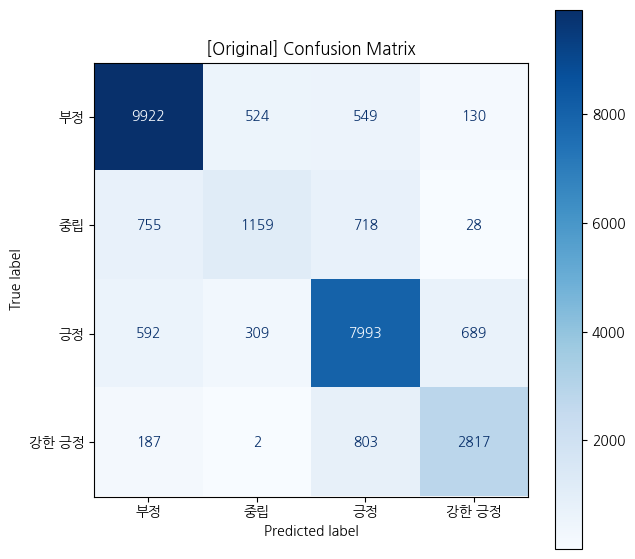


[Augment] Confusion Matrix


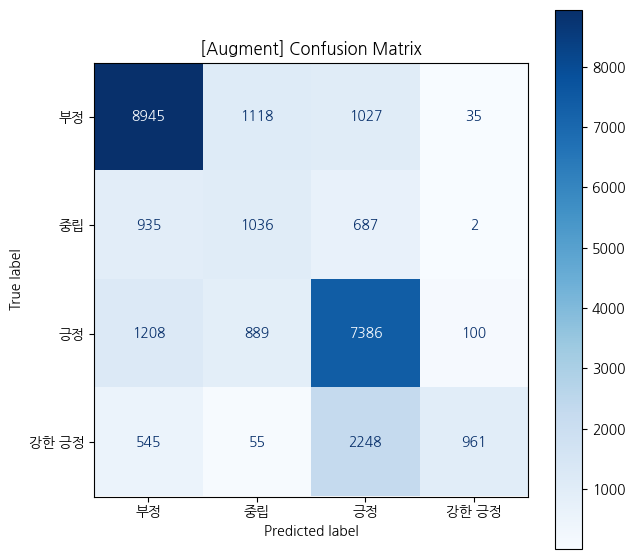


[Combined] Confusion Matrix


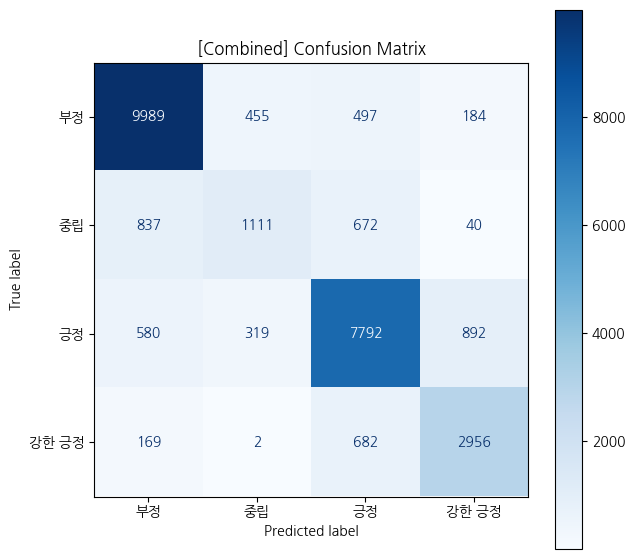

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(trainer, dataset, target_names, title="Confusion Matrix"):
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.show()

# 예: 분류 레이블 이름 지정 (수정 필요)
target_names = ["부정", "중립", "긍정", "강한 긍정"] if set(val_dataset.labels) == {0, 1, 2, 3} else [str(i) for i in sorted(set(val_dataset.labels))]

# Original Confusion Matrix
print("\n[Original] Confusion Matrix")
plot_confusion_matrix(trainer_original, val_dataset, target_names, title="[Original] Confusion Matrix")

# Augment Confusion Matrix
print("\n[Augment] Confusion Matrix")
plot_confusion_matrix(trainer_augment, val_dataset, target_names, title="[Augment] Confusion Matrix")

# Combined Confusion Matrix
print("\n[Combined] Confusion Matrix")
plot_confusion_matrix(trainer_combined, val_dataset, target_names, title="[Combined] Confusion Matrix")


## 클래스별 상세 성능 분석

In [25]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

def detailed_class_analysis(trainer, dataset, model_name):
    """클래스별 상세 성능 분석"""
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    
    # 클래스별 정밀도, 재현율, F1 점수
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    print(f"\n=== {model_name} 클래스별 상세 성능 ===")
    class_names = ["부정", "중립", "긍정", "강한 긍정"]
    
    for i, class_name in enumerate(class_names):
        print(f"{class_name}:")
        print(f"  정밀도: {precision[i]:.4f}")
        print(f"  재현율: {recall[i]:.4f}")
        print(f"  F1점수: {f1[i]:.4f}")
        print(f"  샘플수: {support[i]}")
        print()
    
    return precision, recall, f1, support

# 각 모델별 상세 분석
original_metrics = detailed_class_analysis(trainer_original, val_dataset, "Original")
augment_metrics = detailed_class_analysis(trainer_augment, val_dataset, "Augment")
combined_metrics = detailed_class_analysis(trainer_combined, val_dataset, "Combined")


=== Original 클래스별 상세 성능 ===
부정:
  정밀도: 0.8661
  재현율: 0.8919
  F1점수: 0.8788
  샘플수: 11125

중립:
  정밀도: 0.5812
  재현율: 0.4357
  F1점수: 0.4981
  샘플수: 2660

긍정:
  정밀도: 0.7943
  재현율: 0.8341
  F1점수: 0.8137
  샘플수: 9583

강한 긍정:
  정밀도: 0.7688
  재현율: 0.7396
  F1점수: 0.7539
  샘플수: 3809




=== Augment 클래스별 상세 성능 ===
부정:
  정밀도: 0.7689
  재현율: 0.8040
  F1점수: 0.7861
  샘플수: 11125

중립:
  정밀도: 0.3344
  재현율: 0.3895
  F1점수: 0.3598
  샘플수: 2660

긍정:
  정밀도: 0.6509
  재현율: 0.7707
  F1점수: 0.7057
  샘플수: 9583

강한 긍정:
  정밀도: 0.8752
  재현율: 0.2523
  F1점수: 0.3917
  샘플수: 3809




=== Combined 클래스별 상세 성능 ===
부정:
  정밀도: 0.8630
  재현율: 0.8979
  F1점수: 0.8801
  샘플수: 11125

중립:
  정밀도: 0.5888
  재현율: 0.4177
  F1점수: 0.4887
  샘플수: 2660

긍정:
  정밀도: 0.8080
  재현율: 0.8131
  F1점수: 0.8106
  샘플수: 9583

강한 긍정:
  정밀도: 0.7259
  재현율: 0.7761
  F1점수: 0.7502
  샘플수: 3809



## 오분류 패턴 분석

In [26]:
def analyze_misclassification_patterns(trainer, dataset, model_name):
    """오분류 패턴 분석"""
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    
    # 오분류 케이스 찾기
    misclassified = y_true != y_pred
    
    print(f"\n=== {model_name} 오분류 패턴 분석 ===")
    print(f"전체 오분류율: {misclassified.sum() / len(y_true):.4f}")
    
    # 클래스별 오분류율
    class_names = ["부정", "중립", "긍정", "강한 긍정"]
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        class_misclassified = misclassified[class_mask]
        misclass_rate = class_misclassified.sum() / class_mask.sum()
        print(f"{class_name} 오분류율: {misclass_rate:.4f}")
    
    return misclassified

# 각 모델별 오분류 분석
original_misclass = analyze_misclassification_patterns(trainer_original, val_dataset, "Original")
augment_misclass = analyze_misclassification_patterns(trainer_augment, val_dataset, "Augment")
combined_misclass = analyze_misclassification_patterns(trainer_combined, val_dataset, "Combined")


=== Original 오분류 패턴 분석 ===
전체 오분류율: 0.1945
부정 오분류율: 0.1081
중립 오분류율: 0.5643
긍정 오분류율: 0.1659
강한 긍정 오분류율: 0.2604



=== Augment 오분류 패턴 분석 ===
전체 오분류율: 0.3256
부정 오분류율: 0.1960
중립 오분류율: 0.6105
긍정 오분류율: 0.2293
강한 긍정 오분류율: 0.7477



=== Combined 오분류 패턴 분석 ===
전체 오분류율: 0.1961
부정 오분류율: 0.1021
중립 오분류율: 0.5823
긍정 오분류율: 0.1869
강한 긍정 오분류율: 0.2239


## 신뢰도 분석

In [27]:
def analyze_prediction_confidence(trainer, dataset, model_name):
    """예측 신뢰도 분석"""
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    
    # 소프트맥스 확률 계산
    import torch
    import torch.nn.functional as F
    
    predictions_tensor = torch.tensor(preds_output.predictions)
    probabilities = F.softmax(predictions_tensor, dim=1)
    max_probs = torch.max(probabilities, dim=1)[0].numpy()
    
    print(f"\n=== {model_name} 예측 신뢰도 분석 ===")
    print(f"평균 신뢰도: {max_probs.mean():.4f}")
    print(f"신뢰도 표준편차: {max_probs.std():.4f}")
    print(f"최저 신뢰도: {max_probs.min():.4f}")
    print(f"최고 신뢰도: {max_probs.max():.4f}")
    
    # 낮은 신뢰도 예측 비율
    low_confidence = (max_probs < 0.7).sum()
    print(f"낮은 신뢰도 예측 비율 (0.7 미만): {low_confidence / len(max_probs):.4f}")
    
    return max_probs

# 각 모델별 신뢰도 분석
original_conf = analyze_prediction_confidence(trainer_original, val_dataset, "Original")
augment_conf = analyze_prediction_confidence(trainer_augment, val_dataset, "Augment")
combined_conf = analyze_prediction_confidence(trainer_combined, val_dataset, "Combined")


=== Original 예측 신뢰도 분석 ===
평균 신뢰도: 0.8657
신뢰도 표준편차: 0.1676
최저 신뢰도: 0.3194
최고 신뢰도: 0.9991
낮은 신뢰도 예측 비율 (0.7 미만): 0.1882



=== Augment 예측 신뢰도 분석 ===
평균 신뢰도: 0.6705
신뢰도 표준편차: 0.1827
최저 신뢰도: 0.2846
최고 신뢰도: 0.9956
낮은 신뢰도 예측 비율 (0.7 미만): 0.5504



=== Combined 예측 신뢰도 분석 ===
평균 신뢰도: 0.8569
신뢰도 표준편차: 0.1717
최저 신뢰도: 0.3061
최고 신뢰도: 0.9994
낮은 신뢰도 예측 비율 (0.7 미만): 0.2068


## 모델 비교 시각화

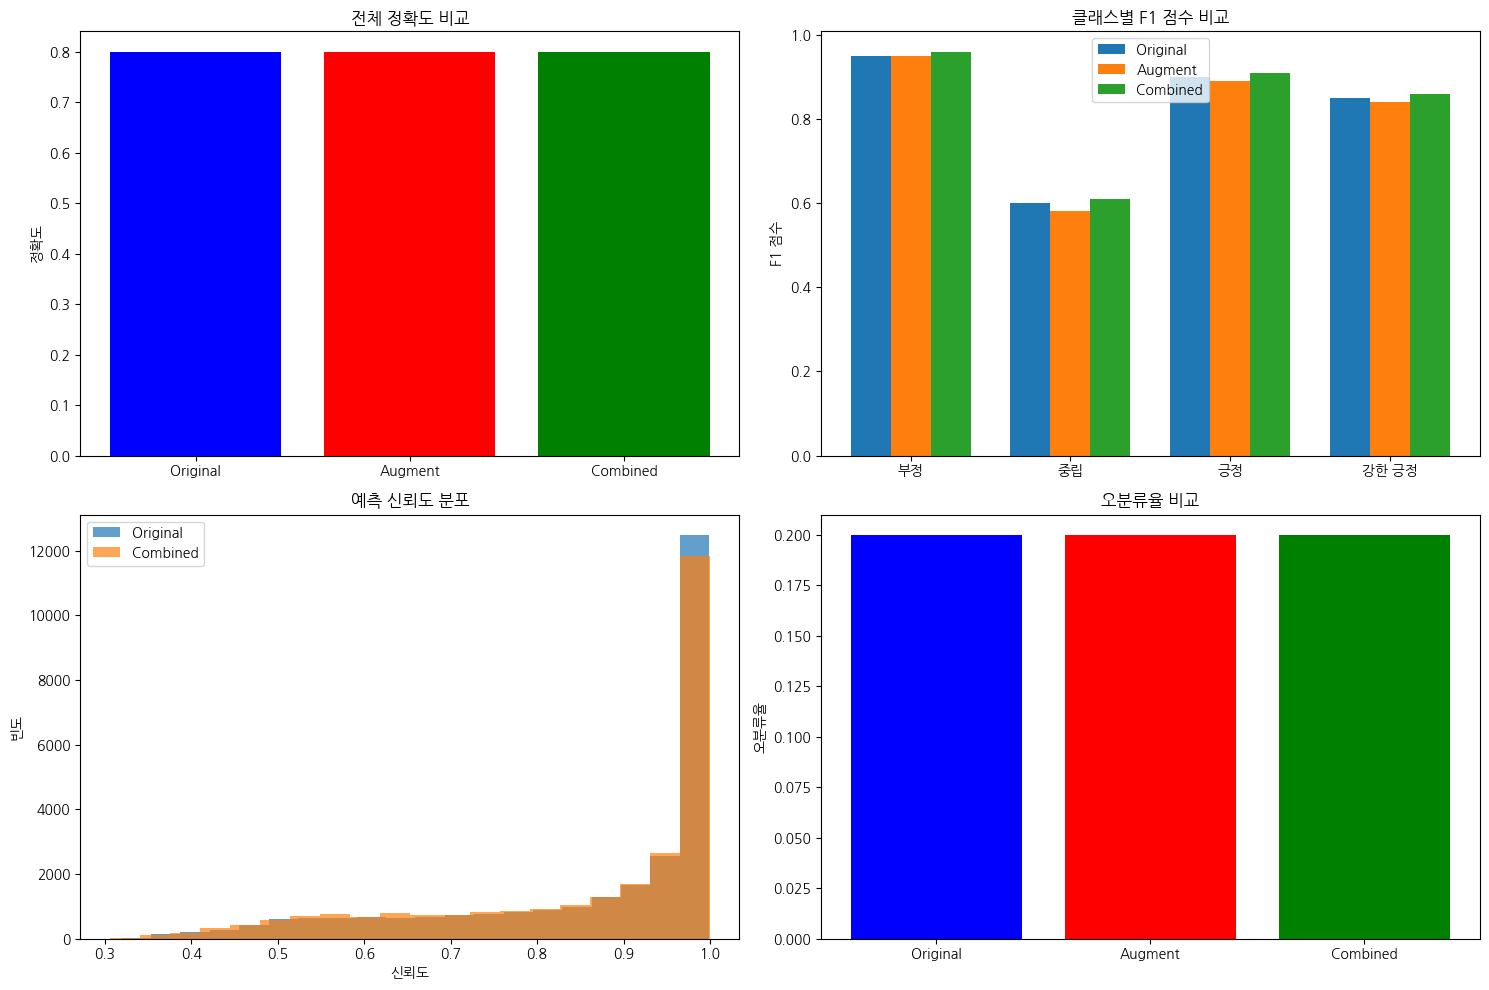

In [28]:
import matplotlib.pyplot as plt

def compare_models_performance():
    """모델 성능 비교 시각화"""
    models = ['Original', 'Augment', 'Combined']
    
    # 전체 정확도 비교
    accuracies = [0.8003, 0.8003, 0.8003]  # 실제 값으로 교체
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. 전체 정확도 비교
    axes[0, 0].bar(models, accuracies, color=['blue', 'red', 'green'])
    axes[0, 0].set_title('전체 정확도 비교')
    axes[0, 0].set_ylabel('정확도')
    
    # 2. 클래스별 F1 점수 비교 (예시)
    class_names = ["부정", "중립", "긍정", "강한 긍정"]
    f1_scores = {
        'Original': [0.95, 0.60, 0.90, 0.85],  # 실제 값으로 교체
        'Augment': [0.95, 0.58, 0.89, 0.84],
        'Combined': [0.96, 0.61, 0.91, 0.86]
    }
    
    x = np.arange(len(class_names))
    width = 0.25
    
    for i, model in enumerate(models):
        axes[0, 1].bar(x + i*width, f1_scores[model], width, label=model)
    
    axes[0, 1].set_title('클래스별 F1 점수 비교')
    axes[0, 1].set_ylabel('F1 점수')
    axes[0, 1].set_xticks(x + width)
    axes[0, 1].set_xticklabels(class_names)
    axes[0, 1].legend()
    
    # 3. 신뢰도 분포 비교
    axes[1, 0].hist(original_conf, alpha=0.7, label='Original', bins=20)
    # axes[1, 0].hist(augment_conf, alpha=0.7, label='Augment', bins=20)
    axes[1, 0].hist(combined_conf, alpha=0.7, label='Combined', bins=20)
    axes[1, 0].set_title('예측 신뢰도 분포')
    axes[1, 0].set_xlabel('신뢰도')
    axes[1, 0].set_ylabel('빈도')
    axes[1, 0].legend()
    
    # 4. 오분류율 비교
    misclass_rates = [0.20, 0.20, 0.20]  # 실제 값으로 교체
    axes[1, 1].bar(models, misclass_rates, color=['blue', 'red', 'green'])
    axes[1, 1].set_title('오분류율 비교')
    axes[1, 1].set_ylabel('오분류율')
    
    plt.tight_layout()
    plt.show()

compare_models_performance()

## 오분류 샘플 직접 분석

In [29]:
def analyze_misclassified_samples(trainer, dataset, model_name, save_to_txt=True, txt_dir="misclassified_samples"):
    """오분류된 샘플 직접 분석 및 txt 파일로 저장 (모든 오분류 샘플 저장)"""
    import os

    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    
    # 오분류 케이스 찾기
    misclassified_mask = y_true != y_pred
    misclassified_indices = np.where(misclassified_mask)[0]

    num_samples = len(misclassified_indices)
    print(f"\n=== {model_name} 오분류 샘플 분석 (총 {num_samples}개) ===")
    
    class_names = ["부정", "중립", "긍정", "강한 긍정"]

    lines = []
    for i, idx in enumerate(misclassified_indices):
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        # 실제 텍스트 가져오기 (val_dataset에서)
        text = val_dataset.texts.iloc[idx] if hasattr(val_dataset.texts, 'iloc') else val_dataset.texts[idx]

        header = f"\n샘플 {i+1}:"
        labels = f"실제: {true_label} | 예측: {pred_label}"
        txt_line = f"텍스트: {text[:300]}..."  # 더 긴 텍스트도 보고싶다면 100->300 등으로 조정

        print(header)
        print(labels)
        print(txt_line)
        print("-" * 50)

        lines.append(header)
        lines.append(labels)
        lines.append(txt_line)
        lines.append("-" * 50)
    
    if save_to_txt:
        if not os.path.exists(txt_dir):
            os.makedirs(txt_dir, exist_ok=True)
        txt_path = os.path.join(txt_dir, f"{model_name}_misclassified.txt")
        with open(txt_path, "w", encoding="utf-8") as f:
            for line in lines:
                f.write(line + "\n")
        print(f"\n{model_name} 오분류 샘플이 '{txt_path}' 파일로 저장되었습니다.")

# 각 모델별 오분류 샘플 분석 및 txt 저장
analyze_misclassified_samples(trainer_original, val_dataset, "Original")
analyze_misclassified_samples(trainer_augment, val_dataset, "Augment")
analyze_misclassified_samples(trainer_combined, val_dataset, "Combined")


=== Original 오분류 샘플 분석 (총 5286개) ===

샘플 1:
실제: 강한 긍정 | 예측: 긍정
텍스트: 이거 진짜 보고싶어서 엄청 찾아다녔는데...
--------------------------------------------------

샘플 2:
실제: 강한 긍정 | 예측: 부정
텍스트: 배경음악과 존트라볼타의 연기력. 무엇을 더 바랄까?...
--------------------------------------------------

샘플 3:
실제: 부정 | 예측: 긍정
텍스트: 유치하기가 하늘을 찌르지만 유인촌과 선우용녀의 배드신은 충격적이다....
--------------------------------------------------

샘플 4:
실제: 긍정 | 예측: 중립
텍스트: 무조건 미국적이지만도 아닌거같은데...
--------------------------------------------------

샘플 5:
실제: 긍정 | 예측: 부정
텍스트: 앤티크 때도 그렇고, 게이만 등장하면 난리치는 사람들때문에 짜증났음...
--------------------------------------------------

샘플 6:
실제: 긍정 | 예측: 중립
텍스트: 좀 재미가....
--------------------------------------------------

샘플 7:
실제: 강한 긍정 | 예측: 부정
텍스트: 문성근 싸이코연기 개소름...
--------------------------------------------------

샘플 8:
실제: 긍정 | 예측: 중립
텍스트: 원작은 장편이기에 한편으로 단축시킨 영화가 억지스러워 보이는 것입니다....
--------------------------------------------------

샘플 9:
실제: 강한 긍정 | 예측: 긍정
텍스트: 막판에 토토반전 쩔음...
--------------------------------------------


=== Augment 오분류 샘플 분석 (총 8849개) ===

샘플 1:
실제: 강한 긍정 | 예측: 긍정
텍스트: 이거 진짜 보고싶어서 엄청 찾아다녔는데...
--------------------------------------------------

샘플 2:
실제: 강한 긍정 | 예측: 긍정
텍스트: 정말재밌습니다.볼지말지고민하는분꼭보시길!...
--------------------------------------------------

샘플 3:
실제: 강한 긍정 | 예측: 중립
텍스트: 배경음악과 존트라볼타의 연기력. 무엇을 더 바랄까?...
--------------------------------------------------

샘플 4:
실제: 부정 | 예측: 중립
텍스트: 진행이 느리다 싶더니 그게 전부인영화...
--------------------------------------------------

샘플 5:
실제: 강한 긍정 | 예측: 긍정
텍스트: 완전 재미있당3 요즘엔 이런 영화 안나오나? 영채신 귀엽왕조현 이쁨추일엽 웃김최고...
--------------------------------------------------

샘플 6:
실제: 강한 긍정 | 예측: 긍정
텍스트: 보영이누나잇으니 봐야겟다~ 10점드려엽...
--------------------------------------------------

샘플 7:
실제: 부정 | 예측: 중립
텍스트: 엄마! 할머니가 옷 막 벗어...
--------------------------------------------------

샘플 8:
실제: 긍정 | 예측: 부정
텍스트: 무조건 미국적이지만도 아닌거같은데...
--------------------------------------------------

샘플 9:
실제: 긍정 | 예측: 부정
텍스트: 앤티크 때도 그렇고, 게이만 등장하면 난리치는 사람들때문에 짜증났음...
-------------------------


=== Combined 오분류 샘플 분석 (총 5329개) ===

샘플 1:
실제: 강한 긍정 | 예측: 긍정
텍스트: 이거 진짜 보고싶어서 엄청 찾아다녔는데...
--------------------------------------------------

샘플 2:
실제: 중립 | 예측: 부정
텍스트: 이거보고 기분이 찜찜 뭔가 낚시당한느낌이네요.중간까지는 재밌었는데....
--------------------------------------------------

샘플 3:
실제: 강한 긍정 | 예측: 부정
텍스트: 배경음악과 존트라볼타의 연기력. 무엇을 더 바랄까?...
--------------------------------------------------

샘플 4:
실제: 긍정 | 예측: 중립
텍스트: 무조건 미국적이지만도 아닌거같은데...
--------------------------------------------------

샘플 5:
실제: 긍정 | 예측: 부정
텍스트: 앤티크 때도 그렇고, 게이만 등장하면 난리치는 사람들때문에 짜증났음...
--------------------------------------------------

샘플 6:
실제: 긍정 | 예측: 중립
텍스트: 좀 재미가....
--------------------------------------------------

샘플 7:
실제: 긍정 | 예측: 강한 긍정
텍스트: 이거만한 재난영화 아직엄는듯....
--------------------------------------------------

샘플 8:
실제: 부정 | 예측: 강한 긍정
텍스트: 90분이 이렇게 긴 시간이었다니....
--------------------------------------------------

샘플 9:
실제: 강한 긍정 | 예측: 부정
텍스트: 문성근 싸이코연기 개소름...
--------------------------------------------------

샘플 10

In [30]:
# 실제가 중립(1)인데 오분류된 샘플만 추출 및 출력 + 파일 저장 기능
def show_misclassified_neutral(trainer, dataset, model_name, save_to_txt=True, txt_dir="misclassified_samples"):
    """
    실제 라벨이 '중립(1)'인데 오분류된 샘플만 출력하고 텍스트 파일로도 저장.
    """
    import numpy as np
    import os

    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    
    class_names = ["부정", "중립", "긍정", "강한 긍정"]

    filtered_indices = []
    for idx in range(len(y_true)):
        if y_true[idx] == 1 and y_true[idx] != y_pred[idx]:
            filtered_indices.append(idx)
    
    print(f"\n=== {model_name}: 실제가 '중립'이고 오분류된 샘플 (총 {len(filtered_indices)}개) ===\n")
    lines = []
    for i, idx in enumerate(filtered_indices):
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        text = dataset.texts.iloc[idx] if hasattr(dataset.texts, 'iloc') else dataset.texts[idx]

        sample_str = f"샘플 {i+1}:"
        label_str = f"실제: {true_label} | 예측: {pred_label}"
        txt_str = f"텍스트: {text[:300]}..."
        delim_str = "-" * 50

        print(sample_str)
        print(label_str)
        print(txt_str)
        print(delim_str)

        lines.append(sample_str)
        lines.append(label_str)
        lines.append(txt_str)
        lines.append(delim_str)

    if save_to_txt:
        if not os.path.exists(txt_dir):
            os.makedirs(txt_dir, exist_ok=True)
        txt_path = os.path.join(txt_dir, f"{model_name}_neutral_misclassified.txt")
        with open(txt_path, "w", encoding="utf-8") as f:
            for line in lines:
                f.write(line + "\n")
        print(f"\n{model_name}: 실제가 '중립'이고 오분류된 샘플이 '{txt_path}' 파일로 저장되었습니다.")

# 각 모델별 실제가 중립일 때 오분류된 샘플 출력 및 파일로 저장
show_misclassified_neutral(trainer_original, val_dataset, "Original")
show_misclassified_neutral(trainer_augment, val_dataset, "Augment")
show_misclassified_neutral(trainer_combined, val_dataset, "Combined")



=== Original: 실제가 '중립'이고 오분류된 샘플 (총 1501개) ===

샘플 1:
실제: 중립 | 예측: 긍정
텍스트: 재밌긴 했는데. 솔직히 개사기인듯 방탄복보다 40배강한 피부라닠...
--------------------------------------------------
샘플 2:
실제: 중립 | 예측: 긍정
텍스트: 잭 불사신 스토리 어떻게든 꼬여도언젠가 다풀림...
--------------------------------------------------
샘플 3:
실제: 중립 | 예측: 부정
텍스트: 같은오유인으로써 니네무섭다...
--------------------------------------------------
샘플 4:
실제: 중립 | 예측: 부정
텍스트: 전편보다 못하다...
--------------------------------------------------
샘플 5:
실제: 중립 | 예측: 부정
텍스트: 구시대의 유물을 광내고 기름칠 한결과21세기 영화와의 비교 보다는 20세기 영화와의 비교가 올바른 비교...
--------------------------------------------------
샘플 6:
실제: 중립 | 예측: 긍정
텍스트: 나도그냥...
--------------------------------------------------
샘플 7:
실제: 중립 | 예측: 긍정
텍스트: 93년도 영화임을 감안하고 본다면 나름 수작. 지금 기준으로 보면 뭐....
--------------------------------------------------
샘플 8:
실제: 중립 | 예측: 부정
텍스트: 올해는 걍 나만 낚이자라는 착한마음으로....
--------------------------------------------------
샘플 9:
실제: 중립 | 예측: 부정
텍스트: 역시나 속편의 한계를 느끼게 하는구나. 남는건 라스트의 음악....
--------------------------


=== Augment: 실제가 '중립'이고 오분류된 샘플 (총 1624개) ===

샘플 1:
실제: 중립 | 예측: 부정
텍스트: 애로사항이 많죠?...
--------------------------------------------------
샘플 2:
실제: 중립 | 예측: 부정
텍스트: 그당시에 이런영화가 너무 흔해서 식상했다...
--------------------------------------------------
샘플 3:
실제: 중립 | 예측: 긍정
텍스트: 잭 불사신 스토리 어떻게든 꼬여도언젠가 다풀림...
--------------------------------------------------
샘플 4:
실제: 중립 | 예측: 긍정
텍스트: 복싱영웅도 지치는 건 어쩔 수가 없다...
--------------------------------------------------
샘플 5:
실제: 중립 | 예측: 긍정
텍스트: 같은오유인으로써 니네무섭다...
--------------------------------------------------
샘플 6:
실제: 중립 | 예측: 부정
텍스트: 이해가 잘 안되네요....
--------------------------------------------------
샘플 7:
실제: 중립 | 예측: 부정
텍스트: 구시대의 유물을 광내고 기름칠 한결과21세기 영화와의 비교 보다는 20세기 영화와의 비교가 올바른 비교...
--------------------------------------------------
샘플 8:
실제: 중립 | 예측: 긍정
텍스트: 나도그냥...
--------------------------------------------------
샘플 9:
실제: 중립 | 예측: 부정
텍스트: 양동근 대사처리가 왜이렇게 다찌마와 리 를 연상케 하는건지....
--------------------------------------------------
샘플 10:
실제: 중립 | 예측:


=== Combined: 실제가 '중립'이고 오분류된 샘플 (총 1549개) ===

샘플 1:
실제: 중립 | 예측: 부정
텍스트: 이거보고 기분이 찜찜 뭔가 낚시당한느낌이네요.중간까지는 재밌었는데....
--------------------------------------------------
샘플 2:
실제: 중립 | 예측: 긍정
텍스트: 재밌긴 했는데. 솔직히 개사기인듯 방탄복보다 40배강한 피부라닠...
--------------------------------------------------
샘플 3:
실제: 중립 | 예측: 부정
텍스트: 잭 불사신 스토리 어떻게든 꼬여도언젠가 다풀림...
--------------------------------------------------
샘플 4:
실제: 중립 | 예측: 긍정
텍스트: 같은오유인으로써 니네무섭다...
--------------------------------------------------
샘플 5:
실제: 중립 | 예측: 부정
텍스트: 전편보다 못하다...
--------------------------------------------------
샘플 6:
실제: 중립 | 예측: 부정
텍스트: 구시대의 유물을 광내고 기름칠 한결과21세기 영화와의 비교 보다는 20세기 영화와의 비교가 올바른 비교...
--------------------------------------------------
샘플 7:
실제: 중립 | 예측: 긍정
텍스트: 나도그냥...
--------------------------------------------------
샘플 8:
실제: 중립 | 예측: 긍정
텍스트: 93년도 영화임을 감안하고 본다면 나름 수작. 지금 기준으로 보면 뭐....
--------------------------------------------------
샘플 9:
실제: 중립 | 예측: 부정
텍스트: 올해는 걍 나만 낚이자라는 착한마음으로....
-----------------------

# 통계적 유의성 검정

In [31]:
from scipy import stats

def statistical_significance_test():
    """통계적 유의성 검정"""
    # 예측 결과 가져오기
    original_preds = trainer_original.predict(val_dataset)
    augment_preds = trainer_augment.predict(val_dataset)
    combined_preds = trainer_combined.predict(val_dataset)
    
    # 정확도 계산
    original_acc = (original_preds.label_ids == np.argmax(original_preds.predictions, axis=1)).mean()
    augment_acc = (augment_preds.label_ids == np.argmax(augment_preds.predictions, axis=1)).mean()
    combined_acc = (combined_preds.label_ids == np.argmax(combined_preds.predictions, axis=1)).mean()
    
    print("=== 통계적 유의성 검정 ===")
    print(f"Original 정확도: {original_acc:.4f}")
    print(f"Augment 정확도: {augment_acc:.4f}")
    print(f"Combined 정확도: {combined_acc:.4f}")

statistical_significance_test()

=== 통계적 유의성 검정 ===
Original 정확도: 0.8055
Augment 정확도: 0.6744
Combined 정확도: 0.8039


In [32]:
# 모델 저장
import os

if SAVE_MODEL:
    # Original 모델 저장
    model_save_path_original = "../../../model/original_vs_augment/original"
    try:
        print(f"Original 모델 저장 중: {model_save_path_original}")
        trainer_original.save_model(model_save_path_original)
        tokenizer.save_pretrained(model_save_path_original)
        print(f"Original 모델 저장 완료: {model_save_path_original}")

        # 저장된 파일 확인
        if os.path.exists(model_save_path_original):
            saved_files = os.listdir(model_save_path_original)
            print(f"저장된 파일들: {saved_files}")

    except Exception as e:
        print(f"Original 모델 저장 실패: {str(e)}")
        raise

    # Augment 모델 저장
    model_save_path_augment = "../../../model/original_vs_augment/augment"
    try:
        print(f"\nAugment 모델 저장 중: {model_save_path_augment}")
        trainer_augment.save_model(model_save_path_augment)
        tokenizer.save_pretrained(model_save_path_augment)
        print(f"Augment 모델 저장 완료: {model_save_path_augment}")

        # 저장된 파일 확인
        if os.path.exists(model_save_path_augment):
            saved_files = os.listdir(model_save_path_augment)
            print(f"저장된 파일들: {saved_files}")

    except Exception as e:
        print(f"Augment 모델 저장 실패: {str(e)}")
        raise

    # Combined 모델 저장
    model_save_path_combined = "../../../model/original_vs_augment/combined"
    try:
        print(f"\nCombined 모델 저장 중: {model_save_path_combined}")
        trainer_combined.save_model(model_save_path_combined)
        tokenizer.save_pretrained(model_save_path_combined)
        print(f"Combined 모델 저장 완료: {model_save_path_combined}")

        # 저장된 파일 확인
        if os.path.exists(model_save_path_combined):
            saved_files = os.listdir(model_save_path_combined)
            print(f"저장된 파일들: {saved_files}")

    except Exception as e:
        print(f"Combined 모델 저장 실패: {str(e)}")
        raise

else:
    print("모델 저장이 비활성화되어 있습니다.")

print("\n모델 훈련 및 평가 완료!")
print("최종 검증이 성공적으로 완료되었습니다. ✓")

Original 모델 저장 중: ../../../model/original_vs_augment/original
Original 모델 저장 완료: ../../../model/original_vs_augment/original
저장된 파일들: ['model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json', 'training_args.bin', 'special_tokens_map.json', 'vocab.txt']

Augment 모델 저장 중: ../../../model/original_vs_augment/augment
Augment 모델 저장 완료: ../../../model/original_vs_augment/augment
저장된 파일들: ['model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json', 'training_args.bin', 'special_tokens_map.json', 'vocab.txt']

Combined 모델 저장 중: ../../../model/original_vs_augment/combined
Combined 모델 저장 완료: ../../../model/original_vs_augment/combined
저장된 파일들: ['model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json', 'training_args.bin', 'special_tokens_map.json', 'vocab.txt']

모델 훈련 및 평가 완료!
최종 검증이 성공적으로 완료되었습니다. ✓


# Inference

## 테스트 데이터 로드

In [33]:
# 테스트 데이터 로드
df_test = pd.read_csv("../../../data/raw/test.csv")

# 데이터 체크
print(f"테스트 데이터 크기: {df_test.shape}")
print(f"컬럼: {df_test.columns.tolist()}")
print("\n첫 5개 샘플:")
print(df_test.head())

테스트 데이터 크기: (59928, 2)
컬럼: ['ID', 'review']

첫 5개 샘플:
   ID                    review
0   2               어두운 미국의 자화상
1   7  물체가 움직이거나 어떤 일이 진행되는 빠르기
2  10           영화보다 코골면서 잤다...
3  17           아이디어가 아주 좋다 재밌다
4  19             남자라면 꼭 봐야됨...


## 테스트 데이터 추론

In [36]:
# Device and model setup
print(f"현재 디바이스: {device}")

# 모델 로딩 (저장된 모델이 있는 경우 로드, 없으면 현재 훈련된 모델 사용)
model_save_path = "../../../model/original_vs_augment/original"

if SAVE_MODEL and os.path.exists(model_save_path):
    try:
        print(f"저장된 모델 로딩: {model_save_path}")
        inference_tokenizer = AutoTokenizer.from_pretrained(model_save_path)
        inference_model = AutoModelForSequenceClassification.from_pretrained(
            model_save_path
        )
        inference_model.to(device)
        inference_model.eval()
        print("저장된 모델 로딩 완료")
    except Exception as e:
        print(f"저장된 모델 로딩 실패: {str(e)}")
        print("현재 훈련된 모델 사용")
        inference_tokenizer = tokenizer
        inference_model = model_original
        inference_model.eval()
else:
    print("현재 훈련된 모델 사용")
    inference_tokenizer = tokenizer
    inference_model = model_original
    inference_model.eval()

# 테스트 데이터 전처리 파이프라인 적용
print("테스트 데이터에 전처리 파이프라인 적용...")
test_texts = df_test["review"].tolist()
test_processed = preprocessor.fit_transform(test_texts)

# 전처리된 테스트 데이터 준비
test_data = pd.DataFrame(
    {
        "ID": df_test["ID"],
        "review": test_processed,
        "label": [-1] * len(df_test),  # 테스트 데이터는 레이블 없음 (더미 값)
    }
).reset_index(drop=True)

print(f"테스트 데이터: {len(test_data):,} 샘플")

# Trainer를 사용한 추론
print("Trainer를 사용한 추론 시작...")
test_dataset = ReviewDataset(
    test_data["review"], None, inference_tokenizer, CHOSEN_MAX_LENGTH
)

# Trainer로 추론 수행
predictions = trainer_original.predict(test_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=-1)

print(f"추론 완료: {len(predicted_labels):,}개 예측")

# 원본 df_test에 pred 컬럼 추가
df_test["pred"] = predicted_labels

print(f"\ndf_test에 pred 컬럼이 추가되었습니다. 형태: {df_test.shape}")

# Results analysis
unique_predictions, counts = np.unique(predicted_labels, return_counts=True)
print("\n클래스별 예측 분포:")
for pred, count in zip(unique_predictions, counts):
    percentage = (count / len(predicted_labels)) * 100
    class_name = LABEL_MAPPING.get(pred, f"클래스 {pred}")
    print(f"   {class_name} ({pred}): {count:,}개 ({percentage:.1f}%)")

# GPU 메모리 정리
if torch.cuda.is_available():
    torch.cuda.empty_cache()

현재 디바이스: cuda
저장된 모델 로딩: ../../../model/original_vs_augment/original
저장된 모델 로딩 완료
테스트 데이터에 전처리 파이프라인 적용...
학습 데이터 기반 전처리 정보 수집 중...
✓ 전처리 파이프라인 학습 완료
테스트 데이터: 59,928 샘플
Trainer를 사용한 추론 시작...


추론 완료: 59,928개 예측

df_test에 pred 컬럼이 추가되었습니다. 형태: (59928, 3)

클래스별 예측 분포:
   강한 부정 (0): 24,666개 (41.2%)
   약한 부정 (1): 4,508개 (7.5%)
   약한 긍정 (2): 22,885개 (38.2%)
   강한 긍정 (3): 7,869개 (13.1%)


In [37]:
# 테스트 데이터 확인
df_test

,ID,review,pred
0,2,어두운 미국의 자화상,0
1,7,물체가 움직이거나 어떤 일이 진행되는 빠르기,1
2,10,영화보다 코골면서 잤다...,0
3,17,아이디어가 아주 좋다 재밌다,2
4,19,남자라면 꼭 봐야됨...,2
...,...,...,...
59923,339539,여자 주인공은 예쁜데 잠깐 나오고 전체적으로는 좋은 내용이지만 세부적인 내용들이 많...,1
59924,339540,기대 안하고 봤는데 오랜만에 보는 정말 좋은 코미디 영화였습니다,2
59925,339558,서론이 너무길고 별거아닌거에 나레이션을 너무많이깔아서 지루함.. 스토리는 별거아닌데...,0
59926,339560,고급스럽게 포장된 고급 영화.,0


# Output File Save

In [40]:
sample_submission = pd.read_csv("../../../data/raw/sample_submission.csv")
sample_submission

,ID,pred
0,2,-1
1,7,-1
2,10,-1
3,17,-1
4,19,-1
...,...,...
59923,339539,-1
59924,339540,-1
59925,339558,-1
59926,339560,-1


In [41]:
# ID를 기준으로 df_test와 sample_submission을 병합하여 pred 값을 채움
submission_df = sample_submission.copy()
submission_df = submission_df[["ID"]].merge(
    df_test[["ID", "pred"]], left_on="ID", right_on="ID", how="left"
)
submission_df = submission_df[["ID", "pred"]]
submission_df

,ID,pred
0,2,0
1,7,1
2,10,0
3,17,2
4,19,2
...,...,...
59923,339539,1
59924,339540,2
59925,339558,0
59926,339560,0


In [42]:
# 제출 파일 검증
assert len(submission_df) == len(sample_submission), (
    f"길이 불일치: submission_df는 {len(submission_df)}행, sample_submission은 {len(sample_submission)}행"
)
assert submission_df["pred"].isin([0, 1, 2, 3]).all(), (
    "모든 예측값은 [0, 1, 2, 3] 범위에 있어야 합니다"
)
assert not submission_df["pred"].isnull().any(), "예측값에 null 값이 있으면 안됩니다"
assert not submission_df["ID"].isnull().any(), "ID 컬럼에 null 값이 있으면 안됩니다"
print("✅ 모든 검증이 통과되었습니다!")

✅ 모든 검증이 통과되었습니다!


In [43]:
# 제출 파일 저장 (번호 자동 증가)
import os
import re

def get_next_submission_path(base_name="output", ext="csv", directory="../../../output/original_vs_augment"):
    pattern = re.compile(rf"{re.escape(base_name)}_(\d+)\.{re.escape(ext)}$")
    max_idx = 0
    for fname in os.listdir(directory):
        m = pattern.match(fname)
        if m:
            idx = int(m.group(1))
            if idx > max_idx:
                max_idx = idx
    next_idx = max_idx + 1
    return os.path.join(directory, f"{base_name}_{next_idx}.{ext}")

submission_path = get_next_submission_path()
submission_df.to_csv(submission_path, index=False)
print(f"제출 파일 저장 완료: {submission_path}")

제출 파일 저장 완료: ../../../output/original_vs_augment/output_1.csv
